x: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
x_noise: [ 2.76405235  2.40015721  3.97873798  6.2408932   6.86755799  5.02272212
  7.95008842  7.84864279  8.89678115 10.4105985  11.14404357 13.45427351
 13.76103773 14.12167502 15.44386323 16.33367433 18.49407907 17.79484174]
y: [ 6.52810469  5.80031442  8.95747597 13.4817864  14.73511598 11.04544424
 16.90017684 16.69728558 18.7935623  21.821197   23.28808714 27.90854701
 28.52207545 29.24335003 31.88772647 33.66734865 37.98815815 36.58968347]


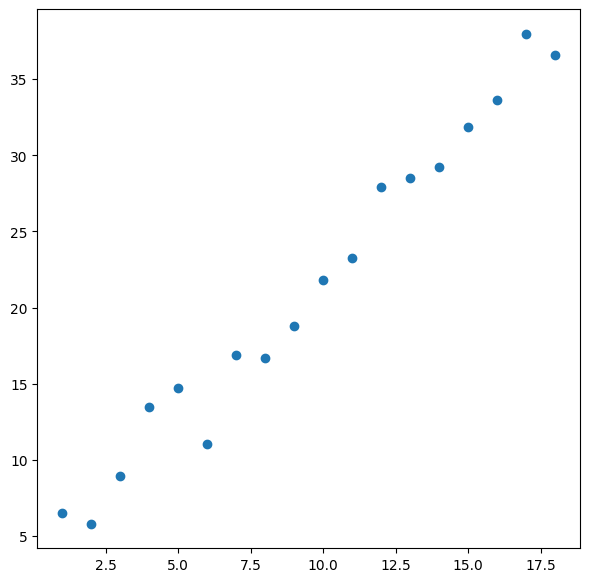

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(0) #保证随机数生成的一致性

N = 18 #数据点个数
x = np.arange(1, N+1)
x_noise = x + np.random.randn(N) #加入随机数噪声干扰
y = 2 * x_noise + 1
print('x:', x)
print('x_noise:', x_noise)
print('y:', y)
plt.figure(figsize=(7,7))
plt.scatter(x, y)
plt.show()

斜率: 1.9074412756437675 截距: 3.2046100921134837


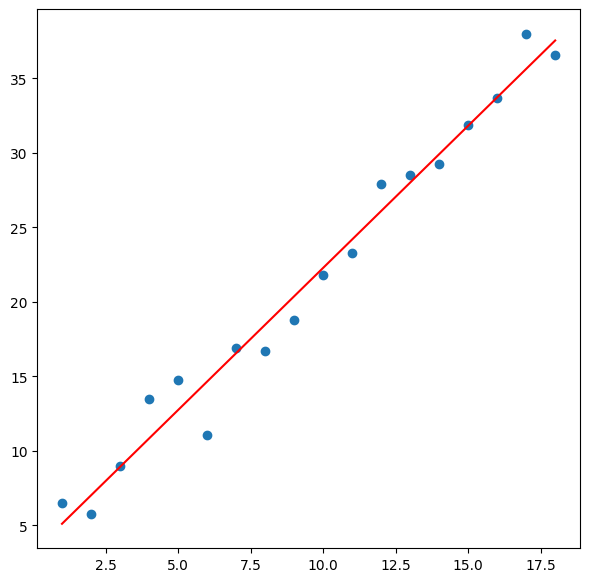

In [2]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(x.reshape(-1, 1), y)
y_pred = lr.predict(x.reshape(-1, 1))
beta = lr.coef_[0]
alpha = lr.intercept_

print('斜率:', beta, '截距:', alpha)
plt.figure(figsize=(7,7))
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.show()

In [4]:
import db

In [5]:
df = db.get_kline("sh.000300", '20100101',"20250101")
df

2025-04-06 11:01:20.933 | INFO     | db:get_kline:24 - exec query : 
    SELECT *
    FROM stock_data.stock_daily
    WHERE code = 'sh.000300' AND date >= '20100101' AND date <= '20250101'ORDER BY date


,code,open,high,low,close,preclose,volume,amount,turn,pctChg,peTTM,pbMRQ,tradestatus,isST,adjfactor
datetime,,,,,,,,,,,,,,,
2010-01-04,sh.000300,3592.4680,3597.7480,3535.2290,3535.2290,3575.6840,6610108000,9.341984e+10,0.006395,-1.131394,NaN,NaN,1,0,1.000000
2010-01-05,sh.000300,3545.1860,3577.5260,3497.6610,3564.0380,3535.2290,8580964100,1.283024e+11,0.008301,0.814914,NaN,NaN,1,0,1.000000
2010-01-06,sh.000300,3558.7000,3588.8320,3541.1730,3541.7270,3564.0380,7847312500,1.210460e+11,0.007591,-0.626004,NaN,NaN,1,0,1.000000
2010-01-07,sh.000300,3543.1600,3558.5560,3452.7690,3471.4560,3541.7270,8035003700,1.204362e+11,0.007773,-1.984089,NaN,NaN,1,0,1.000000
2010-01-08,sh.000300,3456.9080,3482.0830,3426.6980,3480.1300,3471.4560,6079025300,9.019096e+10,0.005880,0.249861,NaN,NaN,1,0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,sh.000300,3987.9557,4007.7626,3969.4766,3985.6291,3983.6882,15939074700,2.992951e+11,0.500028,0.048721,0.0,0.0,1,0,1.000021
2024-12-26,sh.000300,3981.7317,3991.5331,3965.5461,3987.4801,3985.6291,14342528600,3.057699e+11,0.449943,0.046442,0.0,0.0,1,0,1.000021
2024-12-27,sh.000300,3987.0189,4007.1314,3970.9365,3981.0307,3987.4801,16926866600,3.450111e+11,0.530975,-0.161741,0.0,0.0,1,0,1.000021


In [11]:

def calculate_beta(df, window=16):
    if df.shape[0] < window:
        return np.nan,np.nan
    x = df['low'].values
    y = df['high'].values
    lr = LinearRegression().fit(x.reshape(-1, 1), y)
    y_pred = lr.predict(x.reshape(-1, 1))
    beta = lr.coef_[0]
    r2 = r2_score(y, y_pred)
    return beta,r2
N = 18 #计算斜率时的数据点个数
tup_list = [calculate_beta(df,window=N) for df in df.rolling(N)]

df['beta'] = [v[0] for v in tup_list] 
df['r2'] = [v[1] for v in tup_list] 

df.tail(20)


,code,open,high,low,close,preclose,volume,amount,turn,pctChg,peTTM,pbMRQ,tradestatus,isST,adjfactor,beta,r2,std_score,mdf_std_score
datetime,,,,,,,,,,,,,,,,,,,
2024-12-04,sh.000300,3948.1300,3957.3650,3917.7467,3930.5568,3951.8912,17462631800,3.120404e+11,0.551573,-0.539853,0.0,0.0,1,0,1.000021,1.037710,0.897704,0.975851,0.876025
2024-12-05,sh.000300,3916.5638,3936.3358,3910.0834,3921.5881,3930.5568,13853403800,2.577163e+11,0.437572,-0.228179,0.0,0.0,1,0,1.000021,1.032647,0.869805,0.937547,0.815483
2024-12-06,sh.000300,3923.8954,3995.1168,3923.8954,3973.1405,3921.5881,19205790700,3.517517e+11,0.606632,1.314580,0.0,0.0,1,0,1.000021,0.942281,0.845232,0.233363,0.197246
2024-12-09,sh.000300,3970.6628,3995.5116,3948.4206,3966.5708,3973.1405,17595995800,3.082272e+11,0.555699,-0.165353,0.0,0.0,1,0,1.000021,0.919600,0.789297,0.057599,0.045463
2024-12-10,sh.000300,4094.0500,4098.3804,3988.9676,3995.6369,3966.5708,25346379500,4.872780e+11,0.800488,0.732777,0.0,0.0,1,0,1.000021,0.931837,0.737147,0.155346,0.114513
2024-12-11,sh.000300,3988.0179,4005.3253,3977.3522,3988.8308,3995.6369,17725284600,3.107133e+11,0.559799,-0.170338,0.0,0.0,1,0,1.000021,0.858205,0.703380,-0.420091,-0.295484
2024-12-12,sh.000300,3987.1525,4031.7441,3981.3485,4028.5048,3988.8308,18162177700,3.336675e+11,0.573597,0.994627,0.0,0.0,1,0,1.000021,0.836592,0.740975,-0.587741,-0.435502
2024-12-13,sh.000300,4000.9854,4000.9854,3931.7392,3933.1808,4028.5048,23035307900,4.214786e+11,0.727462,-2.366238,0.0,0.0,1,0,1.000021,0.846626,0.750253,-0.507111,-0.380462
2024-12-16,sh.000300,3930.7807,3938.7595,3901.6465,3911.8416,3933.1808,17851125100,3.276191e+11,0.560021,-0.542543,0.0,0.0,1,0,1.000021,0.859416,0.740426,-0.405140,-0.299976


In [6]:
df

,code,open,high,low,close,preclose,volume,amount,turn,pctChg,peTTM,pbMRQ,tradestatus,isST,adjfactor,beta
datetime,,,,,,,,,,,,,,,,
2010-01-04,sh.000300,3592.4680,3597.7480,3535.2290,3535.2290,3575.6840,6610108000,9.341984e+10,0.006395,-1.131394,NaN,NaN,1,0,1.000000,NaN
2010-01-05,sh.000300,3545.1860,3577.5260,3497.6610,3564.0380,3535.2290,8580964100,1.283024e+11,0.008301,0.814914,NaN,NaN,1,0,1.000000,NaN
2010-01-06,sh.000300,3558.7000,3588.8320,3541.1730,3541.7270,3564.0380,7847312500,1.210460e+11,0.007591,-0.626004,NaN,NaN,1,0,1.000000,NaN
2010-01-07,sh.000300,3543.1600,3558.5560,3452.7690,3471.4560,3541.7270,8035003700,1.204362e+11,0.007773,-1.984089,NaN,NaN,1,0,1.000000,NaN
2010-01-08,sh.000300,3456.9080,3482.0830,3426.6980,3480.1300,3471.4560,6079025300,9.019096e+10,0.005880,0.249861,NaN,NaN,1,0,1.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,sh.000300,3987.9557,4007.7626,3969.4766,3985.6291,3983.6882,15939074700,2.992951e+11,0.500028,0.048721,0.0,0.0,1,0,1.000021,1.210094
2024-12-26,sh.000300,3981.7317,3991.5331,3965.5461,3987.4801,3985.6291,14342528600,3.057699e+11,0.449943,0.046442,0.0,0.0,1,0,1.000021,1.180566
2024-12-27,sh.000300,3987.0189,4007.1314,3970.9365,3981.0307,3987.4801,16926866600,3.450111e+11,0.530975,-0.161741,0.0,0.0,1,0,1.000021,1.142391


In [12]:
M = 300

In [13]:
df['std_score'] = (df['beta'] - df['beta'].rolling(M, min_periods=20).mean())/df['beta'].rolling(M, min_periods=20).std()
df['mdf_std_score'] = df['r2'] * df['std_score']
df['rsk_std_score'] = df['beta'] * df['mdf_std_score']



均值：0.179
标准差：0.821
偏度：1.112
峰度：2.425


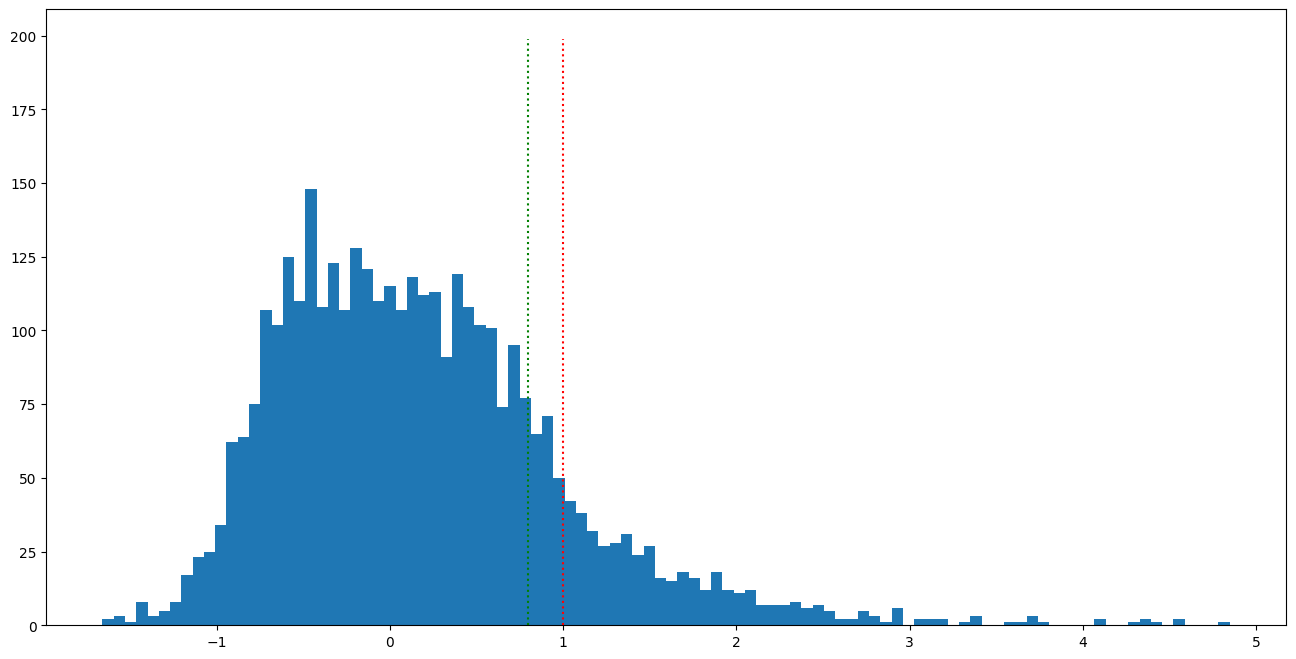

In [14]:
print('均值：%.3f' %df['rsk_std_score'].mean())
print('标准差：%.3f' %df['rsk_std_score'].std())
print('偏度：%.3f' %df['rsk_std_score'].skew())
print('峰度：%.3f' %df['rsk_std_score'].kurt())

y = list(range(200))
plt.figure(figsize=(16,8))
plt.hist(df['rsk_std_score'], bins=100)
plt.plot(len(y)*[0.8], y, color='green', linestyle=':')
plt.plot(len(y)*[1.0], y, color='red', linestyle=':')
plt.show()


均值：0.898
标准差：0.123
偏度：-0.227
峰度：1.083


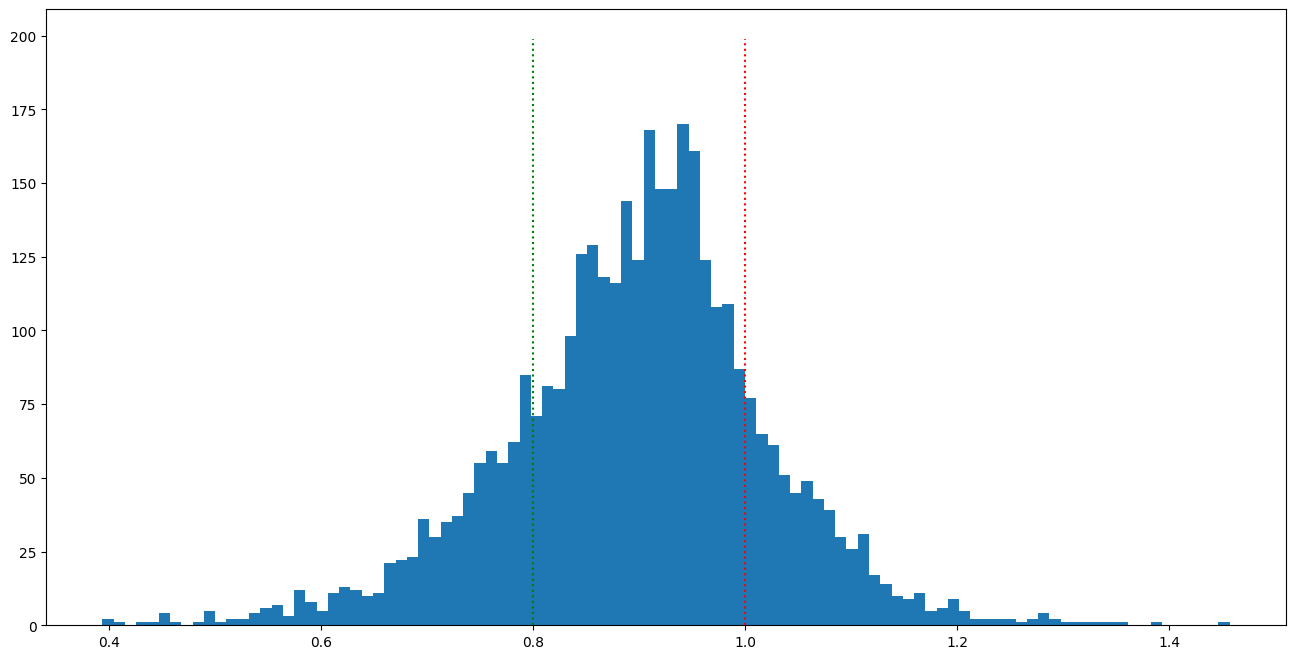

In [7]:
print('均值：%.3f' %df['beta'].mean())
print('标准差：%.3f' %df['beta'].std())
print('偏度：%.3f' %df['beta'].skew())
print('峰度：%.3f' %df['beta'].kurt())

y = list(range(200))
plt.figure(figsize=(16,8))
plt.hist(df['beta'], bins=100)
plt.plot(len(y)*[0.8], y, color='green', linestyle=':')
plt.plot(len(y)*[1.0], y, color='red', linestyle=':')
plt.show()


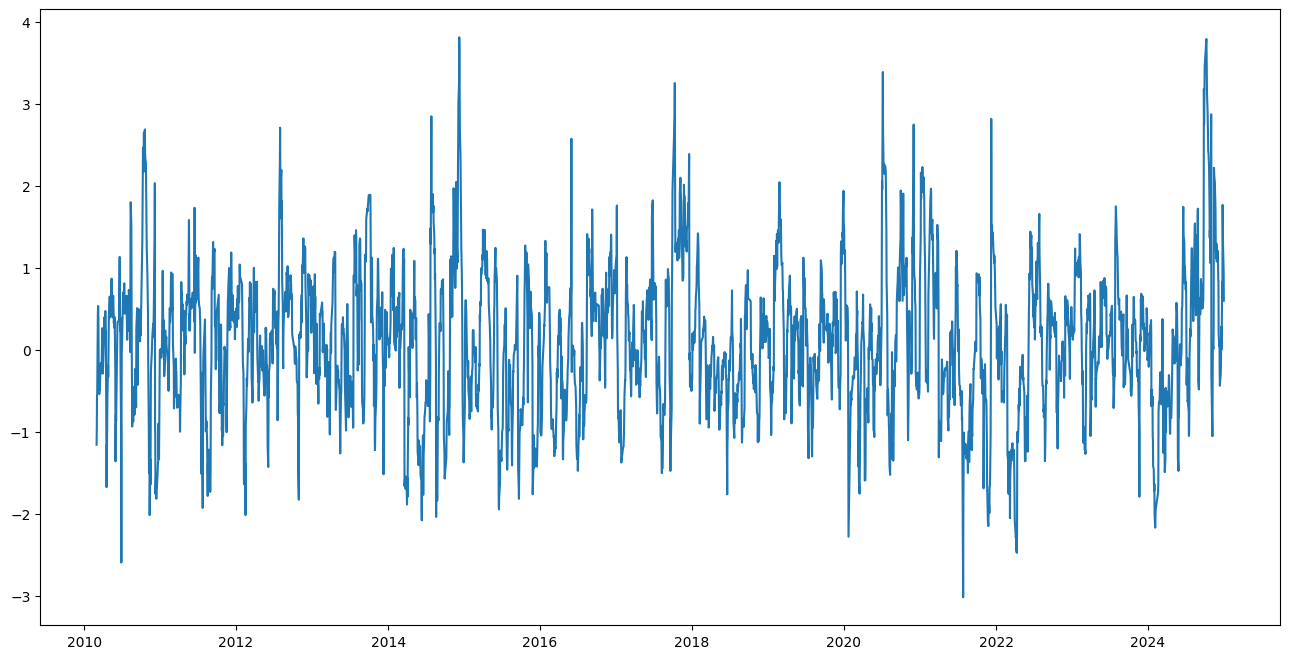

In [10]:
plt.figure(figsize=(16,8))
plt.plot(df['mdf_std_score'])
plt.show()

斜率：1.9074，截距：3.2046
决定系数：0.9753


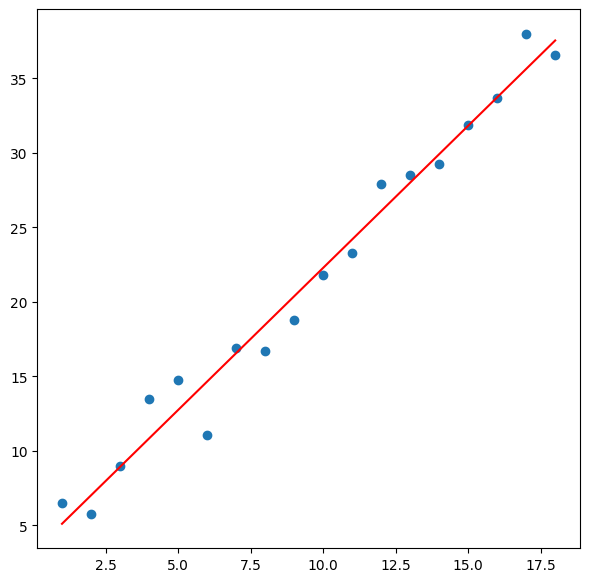

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
np.random.seed(0) #保证随机数生成的一致性

N = 18 #数据点个数
x = np.arange(1, N+1)
x_noise = x + np.random.randn(N) #加入随机数噪声干扰
y = 2 * x_noise + 1

# 最小二乘法回归
lr = LinearRegression().fit(x.reshape(-1, 1), y)
y_pred = lr.predict(x.reshape(-1, 1))
beta = lr.coef_[0]
alpha = lr.intercept_
# 决定系数
r2 = r2_score(y, y_pred)
# rr2 = lr.score(x.reshape(-1, 1), y)


print('斜率：%.4f，截距：%.4f' %(beta,alpha))
print('决定系数：%.4f' %r2)
# print('决定系数：%.4f' %rr2)
plt.figure(figsize=(7,7))
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.show()